<a href="https://colab.research.google.com/github/vohoangloc-32/vibe_network/blob/a_branch/vibe_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

cols = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
X = df[cols].copy()
y = df['Survived']

X['Sex'] = X['Sex'].map({'male': 0, 'female': 1})
X['Age'] = X['Age'].fillna(X['Age'].mean())

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)

In [ ]:
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=[6]),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(1, activation='sigmoid'),
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['binary_accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    patience=10,
    min_delta=0.001,
    restore_best_weights=True,
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    batch_siz0e=32,
    epochs=10,
    callbacks=[early_stopping],
)

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - binary_accuracy: 0.6987 - loss: 0.6321 - val_binary_accuracy: 0.7430 - val_loss: 0.5476
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - binary_accuracy: 0.8075 - loss: 0.4855 - val_binary_accuracy: 0.7542 - val_loss: 0.5080
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - binary_accuracy: 0.8176 - loss: 0.4303 - val_binary_accuracy: 0.7654 - val_loss: 0.4977
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - binary_accuracy: 0.8010 - loss: 0.4370 - val_binary_accuracy: 0.7598 - val_loss: 0.4915
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - binary_accuracy: 0.8276 - loss: 0.4146 - val_binary_accuracy: 0.7709 - val_loss: 0.4893
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - binary_accuracy: 0.8158 - loss: 0.4246 - val_binary_accuracy: 0.7821 - val_loss: 0.4954
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - binary_accuracy: 0.8116 - loss: 0.4226 - val_binary_accuracy: 0.7821 - val_loss: 0.4973
Epoch 

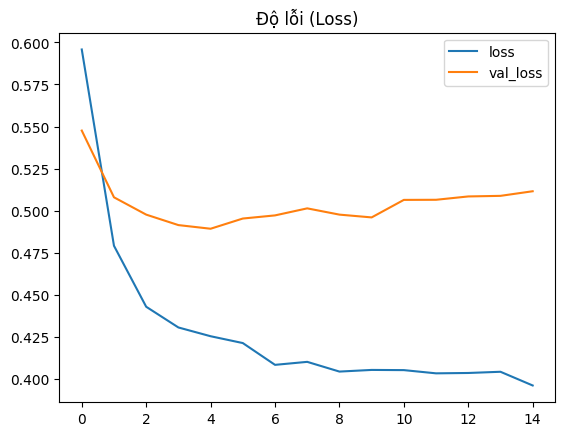

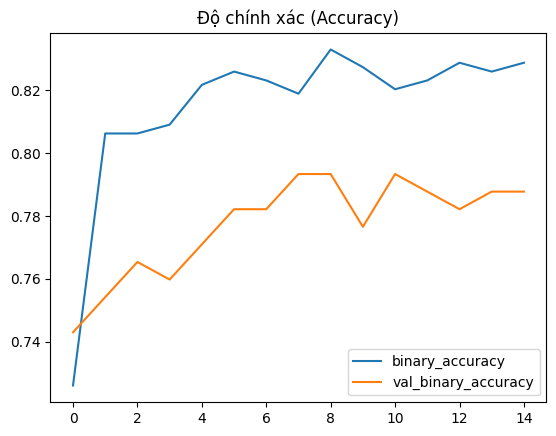

In [ ]:
import matplotlib.pyplot as plt

history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot(title="Độ lỗi (Loss)")
history_df.loc[:, ['binary_accuracy', 'val_binary_accuracy']].plot(title="Độ chính xác (Accuracy)")
plt.show()

In [ ]:

my_data = {
    'Pclass': 1,
    'Sex': 0,
    'Age': 19,
    'SibSp': 0,
    'Parch': 0,
    'Fare': 100.0
}

# Chuyển thành DataFrame để máy hiểu
df_me = pd.DataFrame([my_data])

In [ ]:
# 1. Sơ chế bằng bộ Scaler đã học từ tập Train
me_scaled = scaler.transform(df_me)

# 2. Bắt đầu dự đoán (Kết quả là một xác suất từ 0 đến 1)
prediction = model.predict(me_scaled)

# 3. In kết quả ra màn hình
print(f"--- KẾT QUẢ DỰ ĐOÁN CHO LỘC ---")
print(f"Xác suất sống sót: {prediction[0][0] * 100:.2f}%")

if prediction[0][0] > 0.5:
    print("Trạng thái: CHÚC MỪNG, BẠN CÓ KHẢ NĂNG SỐNG SÓT!")
else:
    print("Trạng thái: CÓ VẺ BẠN NÊN TÌM CÁI PHAO GẤP...")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
--- KẾT QUẢ DỰ ĐOÁN CHO LỘC ---
Xác suất sống sót: 52.87%
Trạng thái: CHÚC MỪNG, BẠN CÓ KHẢ NĂNG SỐNG SÓT!
